In [1]:
# Install required packages
!pip install tidy3d
!pip install optixlog  # Install OptixLog for comprehensive simulation logging

# Add the Coupler SDK to the path for OptixLog
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Coupler', 'sdk'))

In [2]:
!pip install photonforge

  Using cached networkx-2.8.8-py3-none-any.whl.metadata (5.1 kB)
Using cached networkx-2.8.8-py3-none-any.whl (2.0 MB)
  Attempting uninstall: networkx
    Found existing installation: networkx 3.5
    Uninstalling networkx-3.5:
      Successfully uninstalled networkx-3.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.8.8 which is incompatible.


In [3]:
!pip install luxtelligence_lnoi400_forge

In [3]:
import tidy3d as td
import tidy3d.web as web

# Import OptixLog for comprehensive simulation logging
import optixlog
import logging
from datetime import datetime
import json
import time

# Initialize OptixLog client for detailed simulation logging
client = optixlog.init(
    api_key=os.getenv("proj_fEcKVg3ZuIOOWvwwuAP7", "proj_fEcKVg3ZuIOOWvwwuAP7"),
    api_url=os.getenv("OPTIX_API_URL", "https://coupler.onrender.com"),
    run_name=f"MZM_Simulation_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
    project= "Tidy3D",
    config={
        "simulation_type": "Electro-Optic_Modulator",
        "framework": "Tidy3D + PhotonForge",
        "technology": "LNOI400",
        "description": "Mach-Zehnder Modulator simulation using Tidy3D and PhotonForge"
    },
    create_project_if_not_exists=True
)

print("🔬 OptixLog initialized for Tidy3D MZM simulation")
print(f"📊 Run ID: {client.run_id}")
print(f"📝 Project: Tidy3D MZM Electro-Optic Modulator Analysis")

# Log simulation initialization - only numeric values
client.log(0,
    step_phase=0,
    timestamp_seconds=time.time()
)

[optixlog] Master process initialized project: Tidy3D
[optixlog] Master process initialized run: d2442b6a-9f5e-414f-b3c1-a69e4e5ca73b
🔬 OptixLog initialized for Tidy3D MZM simulation
📊 Run ID: d2442b6a-9f5e-414f-b3c1-a69e4e5ca73b
📝 Project: Tidy3D MZM Electro-Optic Modulator Analysis


In [4]:
web.configure("DS9ueJ6ZhFkp7FI1jZ7ltuF63KKFGx606ce5ZqPd1cYPDE1D")

Configured successfully.


In [5]:
web.test()

18:51:39 EST Authentication configured successfully!

In [7]:
!tidy3d configure --apikey=DS9ueJ6ZhFkp7FI1jZ7ltuF63KKFGx606ce5ZqPd1cYPDE1D
!export OPTIX_API_KEY="proj_fEcKVg3ZuIOOWvwwuAP7"

Configured successfully.


In [ ]:
import luxtelligence_lnoi400_forge as lxt
import numpy as np
import photonforge as pf
import tidy3d as td
from matplotlib import pyplot as plt

# Log simulation setup - only numeric values
# Parse version numbers to float (e.g., "2.9.1" -> 2.91)
def version_to_float(version_str):
    try:
        parts = version_str.split('.')
        return float(f"{parts[0]}.{''.join(parts[1:3])}")
    except:
        return 0.0

client.log(1,
    step_phase=1,
    tidy3d_version_float=version_to_float(td.__version__),
    numpy_version_float=version_to_float(np.__version__)
)

print("📚 Libraries imported successfully")
print("🔧 Setting up Tidy3D MZM simulation environment")

td.config.logging_level = "ERROR"

📚 Libraries imported successfully
🔧 Setting up Tidy3D MZM simulation environment


In [ ]:
# Initialize technology stack
tech = lxt.lnoi400(include_substrate=True, include_top_opening=True)
pf.config.default_technology = tech

# Log technology configuration - only numeric values
client.log(2,
    step_phase=2,
    include_substrate=1.0,  # 1.0 for True
    include_top_opening=1.0,  # 1.0 for True
    insulator_thickness_nm=400.0
)

print("🏗️ LNOI400 technology stack configured")
print("📐 Substrate and top opening included in simulation")

🏗️ LNOI400 technology stack configured
📐 Substrate and top opening included in simulation


In [11]:
# Optical Waveguide Configuration
lda = 0.775  # Wavelength in micrometers
wg_spec = tech.ports["RWG3000"]

# Log optical waveguide parameters - only numeric values
client.log(3,
    step_phase=3,
    wavelength_um=lda,
    frequency_hz=float(pf.C_0 / lda),
    waveguide_width_nm=3000.0
)

print(f"🔍 Optical wavelength: {lda} μm")
print(f"📡 Frequency: {pf.C_0 / lda:.2e} Hz")
print("🌊 Configuring RWG3000 rib waveguide")

# Plot and log waveguide visualization
fig = pf.tidy3d_plot(wg_spec, frequency=pf.C_0 / lda)
plt.savefig("waveguide_plot.png", dpi=150, bbox_inches='tight')
img = Image.open("waveguide_plot.png")
client.log_image("waveguide_plot", img, meta={"waveguide_type": "RWG3000", "wavelength_um": lda})
plt.close()

🔍 Optical wavelength: 0.775 μm
📡 Frequency: 3.87e+14 Hz
🌊 Configuring RWG3000 rib waveguide


In [12]:
# Optical Mode Analysis
print("🔬 Starting optical mode analysis...")
print("📊 Computing effective index and group index...")

# Log optical mode computation start - only numeric values
client.log(4,
    step_phase=4,
    frequency_hz=float(pf.C_0 / lda),
    group_index_flag=1.0  # 1.0 for True
)

# Record computation start time
mode_start_time = time.time()

opt_solver = pf.port_modes(wg_spec, [pf.C_0 / lda], group_index=True)

# Record computation time
mode_computation_time = time.time() - mode_start_time

# Log computation results
mode_data = opt_solver.data.to_dataframe()
effective_index = mode_data['n_eff'].iloc[0]
group_index = mode_data['n_group'].iloc[0] if 'n_group' in mode_data.columns else "N/A"

client.log(5,
    simulation_phase="optical_mode_computation_complete",
    effective_index=float(effective_index),
    group_index=float(group_index) if group_index != "N/A" else None,
    mode_count=len(mode_data),
    computation_time_seconds=mode_computation_time,
    status="completed"
)

print(f"✅ Effective index: {effective_index:.4f}")
if group_index != "N/A":
    print(f"✅ Group index: {group_index:.4f}")

_ = opt_solver.plot_field("E", "abs^2", mode_index=0)

opt_solver.data.to_dataframe()

🔬 Starting optical mode analysis...
📊 Computing effective index and group index...
Uploading task 'Mode-ModeSolver'…
Starting task 'Mode-ModeSolver': https://tidy3d.simulation.cloud/workbench?taskId=mo-122df655-1cc0-4c7a-b547-850b424a598b


18:16:35 EDT ERROR: Simulation cannot be submitted due to an expired account    
             balance.                                                           

WebError: Simulation cannot be submitted due to an expired account balance.

In [13]:
# Coplanar Waveguide (CPW) Configuration
print("📡 Setting up coplanar waveguide for RF analysis...")

# Define RF frequency range from 1 GHz to 65 GHz
rf_freqs = np.linspace(1e9, 65e9, 20)

# Log RF frequency range - only numeric values
client.log(6,
    step_phase=6,
    frequency_min_ghz=float(rf_freqs[0]/1e9),
    frequency_max_ghz=float(rf_freqs[-1]/1e9),
    frequency_points=float(len(rf_freqs)),
    frequency_step_ghz=float((rf_freqs[1]-rf_freqs[0])/1e9)
)

cpw_spec = tech.ports["UniCPW-EO"]

print(f"📊 RF frequency range: {rf_freqs[0]/1e9:.1f} - {rf_freqs[-1]/1e9:.1f} GHz")
print(f"🔢 Frequency points: {len(rf_freqs)}")
print("⚡ Configuring UniCPW-EO (Uniplanar Coplanar Waveguide Electro-Optic)")

ax = pf.tidy3d_plot(cpw_spec, frequency=rf_freqs[0])

ic = cpw_spec.to_tidy3d_impedance_calculator()
ic.voltage_integral.plot(ax=ax, x=0)
ic.current_integral.plot(ax=ax, x=0)

# Save and log CPW plot
plt.savefig("cpw_plot.png", dpi=150, bbox_inches='tight')
img = Image.open("cpw_plot.png")
client.log_image("cpw_plot", img, meta={"cpw_type": "UniCPW-EO", "frequency_ghz": float(rf_freqs[0]/1e9)})
plt.close()

📡 Setting up coplanar waveguide for RF analysis...
📊 RF frequency range: 1.0 - 65.0 GHz
🔢 Frequency points: 20
⚡ Configuring UniCPW-EO (Uniplanar Coplanar Waveguide Electro-Optic)


In [14]:
# CPW Mode Analysis
print("🔬 Computing CPW modes and impedance...")
print("📊 Analyzing RF field distribution and characteristic impedance...")

# Log CPW mode computation start - only numeric values
client.log(7,
    step_phase=7,
    frequency_min_ghz=float(rf_freqs[0]/1e9),
    frequency_max_ghz=float(rf_freqs[-1]/1e9),
    frequency_points=float(len(rf_freqs))
)

# Record computation start time
cpw_start_time = time.time()

cpw_solver, z0 = pf.port_modes(cpw_spec, rf_freqs, impedance=True)

# Record computation time
cpw_computation_time = time.time() - cpw_start_time

# Extract impedance data
impedance_real = z0.real.values
impedance_imag = z0.imag.values
frequencies_ghz = z0.f * 1e-9

# Log CPW results
client.log(8,
    step_phase=8,
    impedance_at_1ghz=float(impedance_real[0]),
    impedance_at_65ghz=float(impedance_real[-1]),
    impedance_variation=float(np.max(impedance_real) - np.min(impedance_real)),
    frequency_range_ghz_min=float(frequencies_ghz[0]),
    frequency_range_ghz_max=float(frequencies_ghz[-1]),
    computation_time_seconds=cpw_computation_time
)

print(f"✅ Characteristic impedance at 1 GHz: {impedance_real[0]:.1f} Ω")
print(f"✅ Characteristic impedance at 65 GHz: {impedance_real[-1]:.1f} Ω")
print(f"📈 Impedance variation: {np.max(impedance_real) - np.min(impedance_real):.1f} Ω")

fig, ax = plt.subplots(1, 2, figsize=(9, 3), tight_layout=True)

cpw_solver.plot_field("Ey", "real", f=rf_freqs[0].item(), robust=False, ax=ax[0])
ax[1].plot(z0.f * 1e-9, z0.real)
_ = ax[1].set(xlabel="Frequencies (GHz)", ylabel="Re{Z₀} (Ω)")

🔬 Computing CPW modes and impedance...
📊 Analyzing RF field distribution and characteristic impedance...
Uploading task 'Mode-ModeSolver'…
Starting task 'Mode-ModeSolver': https://tidy3d.simulation.cloud/workbench?taskId=mo-09d602a7-d247-47ae-837b-a2ee43a58e18


18:17:18 EDT ERROR: Simulation cannot be submitted due to an expired account    
             balance.                                                           

WebError: Simulation cannot be submitted due to an expired account balance.

In [15]:
# Computation of Vπ·L
cpw_paths = cpw_spec.path_profiles
cpw_paths

{'gnd1': (180.0, 99.0, (21, 0)),
 'gnd0': (180.0, -99.0, (21, 0)),
 'signal': (10.0, 0.0, (21, 0))}

In [16]:
ground_width, ground_offset, _ = cpw_paths["gnd1"]
signal_width, _, _ = cpw_paths["signal"]
offset = (ground_offset - ground_width / 2 + signal_width / 2) / 2
gap = ground_offset - ground_width / 2 - signal_width / 2

# Log CPW geometry parameters
client.log(step=9,
    step_phase=9,
    offset_um=float(offset),
    gap_um=float(gap),
    ground_width_um=float(ground_width),
    signal_width_um=float(signal_width)
)

print(f"Offset: {offset} μm\nGap: {gap} μm")

Offset: 7.0 μm
Gap: 4.0 μm


In [17]:
mzm_spec = cpw_spec.combined_with(wg_spec, offset).combined_with(wg_spec, -offset)

ax = pf.tidy3d_plot(mzm_spec, frequency=rf_freqs[0])
ic.voltage_integral.plot(ax=ax, x=0)
ic.current_integral.plot(ax=ax, x=0)

# Save and log MZM spec plot
plt.savefig("mzm_spec_plot.png", dpi=150, bbox_inches='tight')
img = Image.open("mzm_spec_plot.png")
client.log_image("mzm_spec_plot", img, meta={"frequency_ghz": float(rf_freqs[0]/1e9)})
plt.close()

In [19]:
# Get the minimal grid spacing from the optical simulation to use here as well
dy = np.diff(opt_solver.simulation.grid.boundaries.z).min()
dz = np.diff(opt_solver.simulation.grid.boundaries.z).min()

# Mesh override parameters
dl = (None, dy, dz)
ln_thickness = tech.parametric_kwargs["ln_thickness"]
size = (td.inf, gap, ln_thickness)

mzm_solver = mzm_spec.to_tidy3d(frequencies=rf_freqs)
mzm_solver = mzm_solver.updated_copy(
    "simulation/grid_spec",
    override_structures=[
        td.MeshOverrideStructure(
            geometry=td.Box(center=(0, -offset, ln_thickness / 2), size=size), dl=dl
        ),
        td.MeshOverrideStructure(
            geometry=td.Box(center=(0, offset, ln_thickness / 2), size=size), dl=dl
        ),
    ],
)
ax = mzm_solver.plot()
mzm_solver.plot_grid(ax=ax)
_ = ax.set(xlim=(offset - 4, offset + 4), ylim=(-1, 3))

NameError: name 'opt_solver' is not defined

In [20]:
# Log MZM solver computation start - only numeric values
client.log(10,
    step_phase=10,
    frequency_points=float(len(rf_freqs)),
    frequency_min_ghz=float(rf_freqs[0]/1e9),
    frequency_max_ghz=float(rf_freqs[-1]/1e9)
)

# Record computation start time
mzm_start_time = time.time()

mzm_solver = pf.port_modes(mzm_solver)

# Record computation time
mzm_computation_time = time.time() - mzm_start_time

# Log MZM solver completion - only numeric values
client.log(11,
    step_phase=11,
    computation_time_seconds=mzm_computation_time
)

# Plot and log MZM field
fig = mzm_solver.plot_field("Ey", "real", f=rf_freqs[0].item(), robust=True)
plt.savefig("mzm_field_ey.png", dpi=150, bbox_inches='tight')
img = Image.open("mzm_field_ey.png")
client.log_image("mzm_field_ey", img, meta={"field_component": "Ey", "frequency_ghz": float(rf_freqs[0]/1e9)})
plt.close()

SyntaxError: unterminated string literal (detected at line 7) (1469773147.py, line 7)

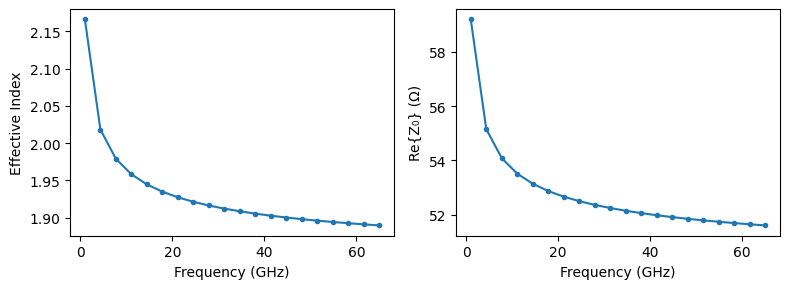

In [ ]:
n_eff = mzm_solver.data.n_eff.isel(mode_index=0).values
z0 = ic.compute_impedance(mzm_solver.data)

# Log MZM analysis results
client.log(11,
    simulation_phase="mzm_analysis_results",
    effective_index_min=float(np.min(n_eff)),
    effective_index_max=float(np.max(n_eff)),
    effective_index_variation=float(np.max(n_eff) - np.min(n_eff)),
    impedance_min_ohm=float(np.min(np.real(z0))),
    impedance_max_ohm=float(np.max(np.real(z0))),
    impedance_variation_ohm=float(np.max(np.real(z0)) - np.min(np.real(z0))),
    frequency_points=len(rf_freqs),
    status="completed"
)

fig, ax = plt.subplots(1, 2, figsize=(8, 3), tight_layout=True)

ax[0].plot(rf_freqs * 1e-9, n_eff, ".-")
ax[0].set(ylabel="Effective Index", xlabel="Frequency (GHz)")

ax[1].plot(rf_freqs * 1e-9, np.real(z0), ".-")
ax[1].set(ylabel="Re{Z₀ partially (Ω)", xlabel="Frequency (GHz)")
plt.savefig("mzm_effective_index_impedance.png", dpi=150, bbox_inches='tight')
img = Image.open("mzm_effective_index_impedance.png")
client.log_image("mzm_effective_index_impedance", img, meta={"frequency_range_ghz": [rf_freqs[0]/1e9, rf_freqs[-1]/1e9]})
plt.close()

# Export MZM analysis data to CSV
mzm_df = pd.DataFrame({
    'frequency_GHz': rf_freqs * 1e-9,
    'effective_index': n_eff,
    'impedance_real_ohm': np.real(z0),
    'impedance_imag_ohm': np.imag(z0)
})
mzm_df.to_csv("mzm_analysis_data.csv_ids=False)
client.log_file("mzm_analysis_data", "mzm_analysis_data.csv", content_type="text/csv")

In [21]:
v0 = ic.voltage_integral.compute_voltage(mzm_solver.data)

ey_norm = (mzm_solver.data.Ey / v0).isel(f=0, mode_index=0, drop=True).abs
ey_norm = ey_norm.assign_coords(y=ey_norm.y - offset)

ey_norm.isel(x=0).transpose("z", "y").plot(robust=True)
# _ = plt.gca().set(xlim=(-gap, gap), ylim=(-1, 4))

NameError: name 'mzm_solver' is not defined

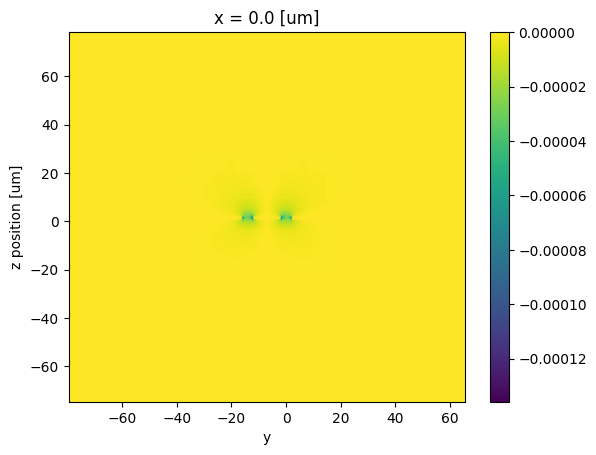

In [ ]:
ln = td.material_library["LiNbO3"]["Zelmon1997"](optical_axis=1)
eps_o, eps_e, _ = (e.real for e in ln.eps_diagonal(pf.C_0 / lda))

n_e = eps_e**0.5
r33 = 30.9e-6  # μm/V

# Log electro-optic material properties - only numeric values
client.log(13,
    step_phase=13,
    ordinary_index=float(n_e),
    extraordinary_index=float(eps_o**0.5),
    r33_coefficient=float(r33),
    wavelength_um=float(lda)
)

# Index variation derived from the RF field
Δn = -0.5 * n_e**3 * r33 * ey_norm

# Log index variation analysis - only numeric values
client.log(14,
    step_phase=14,
    delta_n_min=float(np.min(Δn.values)),
    delta_n_max=float(np.max(Δn.values)),
    delta_n_range=float(np.max(Δn.values) - np.min(Δn.values)),
    r33_coefficient=float(r33)
)

# We plot the whole domain, but the perturbation will only take effect over the LiNbO₃, not everywhere
Δn.isel(x=0).transpose("z", "y").plot(robust=False)

# Save and log index variation plot
plt.savefig("index_variation_plot.png", dpi=150, bbox_inches='tight')
img = Image.open("index_variation_plot.png")
client.log_image("index_variation_plot", img, meta={"material": "LiNbO3", "r33": float(r33)})
plt.close()

In [ ]:
# Use a single data point for the homogeneous directions
eps_o_array = td.SpatialDataArray(
    np.full((1, 1, 1), eps_o), coords={"x": [0], "y": [0], "z": [0]}
)


def perturbed_solver(voltage):
    perturbed_ln = td.CustomAnisotropicMedium(
        xx=td.CustomMedium(permittivity=eps_o_array, subpixel=True),
        yy=td.CustomMedium(permittivity=(n_e + voltage * Δn) ** 2, subpixel=True),
        zz=td.CustomMedium(permittivity=eps_o_array, subpixel=True),
    )
    # We use the same optical waveguide as before and change the LiNbO₃ medium in the technology
    return pf.port_modes(
        wg_spec, [pf.C_0 / lda], technology=lxt.lnoi400(ln=perturbed_ln)
    )

Uploading task 'Mode-ModeSolver'…
Starting task 'Mode-ModeSolver': https://tidy3d.simulation.cloud/workbench?taskId=mo-a97dd52f-494a-4ab9-970a-c47291ddba70
Progress: 100%
Uploading task 'Mode-ModeSolver'…
Starting task 'Mode-ModeSolver': https://tidy3d.simulation.cloud/workbench?taskId=mo-014fbdaa-9d3f-4281-8047-fdb36e17413e
Progress: 100%
Uploading task 'Mode-ModeSolver'…
Starting task 'Mode-ModeSolver': https://tidy3d.simulation.cloud/workbench?taskId=mo-61642184-881f-4b18-8184-8c37636bb6df
Progress: 100%
Uploading task 'Mode-ModeSolver'…
Starting task 'Mode-ModeSolver': https://tidy3d.simulation.cloud/workbench?taskId=mo-ce3838ec-076c-4010-8d77-aa1a3f75204a
Progress: 100%
Uploading task 'Mode-ModeSolver'…
Starting task 'Mode-ModeSolver': https://tidy3d.simulation.cloud/workbench?taskId=mo-f5863c1a-3f90-440c-83fc-7846507c8920
Progress: 100%
Vπ·L (single-drive) = 4.88 V·cm
Vπ·L (push-pull)    = 2.44 V·cm


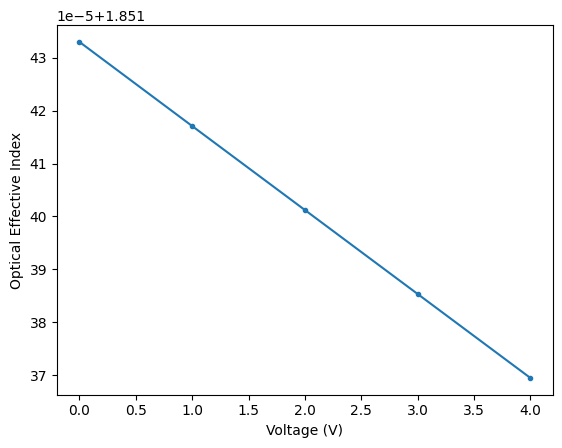

In [ ]:
voltages = np.arange(5)

# Log voltage sweep start
client.log(14,
    simulation_phase="voltage_sweep_start",
    voltage_range_v=[float(np.min(voltages)), float(np.max(voltages))],
    voltage_points=len(voltages),
    status="started"
)

# Record computation start time
voltage_sweep_start_time = time.time()

n_eff = [
    perturbed_solver(v).data.n_eff.isel(mode_index=0, f=0).item() for v in voltages
]

# Record computation time
voltage_sweep_time = time.time() - voltage_sweep_start_time

# Log voltage sweep results
client.log(15,
    simulation_phase="voltage_sweep_complete",
    effective_index_at_0v=float(n_eff[0]),
    effective_index_at_max_v=float(n_eff[-1]),
    effective_index_variation=float(n_eff[-1] - n_eff[0]),
    voltage_sweep_time_seconds=voltage_sweep_time,
    linearity_check="The variation is quite linear",
    status="completed"
)

_ = plt.plot(voltages, n_eff, ".-")
plt.gca().set(xlabel="Voltage (V)", ylabel="Optical Effective Index")

# The variation is quite linear, so we simply use the largest interval
dneff_dV = abs(n_eff[-1] - n_eff[0]) / (voltages[-1] - voltages[0])

vpil = 0.5 * lda / dneff_dV  # in V·μm"

print(f"Vπ·L (single-drive) = {vpil * 1e-4:.2f} V·cm")
print(f"Vπ·L (push-pull)    = {vpil * 1e-4 / 2:.2f} V·cm")

In [ ]:
z_load = 50  # Ω
z0_low_freq = z0.isel(f=0).real.item()

vpil_mismatch = vpil * (2 * z0_low_freq) / (z0_low_freq + z_load)

print(f"Mismatched Vπ·L (single-drive) = {vpil_mismatch * 1e-4:.2f} V·cm")
print(f"Mismatched Vπ·L (push-pull)    = {vpil_mismatch * 1e-4 / 2:.2f} V·cm")

Mismatched Vπ·L (single-drive) = 5.29 V·cm
Mismatched Vπ·L (push-pull)    = 2.65 V·cm


In [ ]:
# Chip Layout
opt_tech = lxt.lnoi400()
pf.config.default_technology = opt_tech

# Single mode waveguide as default
routing_spec = opt_tech.ports["RWG1000"]
pf.config.default_kwargs = {"radius": 70, "port_spec": routing_spec}

freqs = td.frequencies.c_band()

In [ ]:
from photonforge.live_viewer import LiveViewer

viewer = LiveViewer()

<ipython-input-25-86f82ea653fa>:1: UserWarning: The 'live_viewer' submodule requires more dependencies than the base photonforge module. Please install all dependencies by, e.g., 'pip install photonforge[live_viewer]'.
  from photonforge.live_viewer import LiveViewer


In [ ]:
#MZ Arms
@pf.parametric_component()
def gsg_pad(*, pad_size=(100, 100), pad_gap=50):
    c = pf.Component()
    c.add_terminal(
        pf.Terminal(
            "TL", pf.Rectangle(center=(0, -pad_size[1] - pad_gap), size=pad_size)
        ),
        "G0",
    )
    c.add_terminal(pf.Terminal("TL", pf.Rectangle(center=(0, 0), size=pad_size)), "S")
    c.add_terminal(
        pf.Terminal(
            "TL", pf.Rectangle(center=(0, pad_size[1] + pad_gap), size=pad_size)
        ),
        "G1",
    )
    return c


pad = gsg_pad()
viewer(pad)

In [ ]:
@pf.parametric_component()
def mzm_arms(*, length=3000, taper_length=150):
    c = pf.Component()

    tline = c.add_reference(pf.parametric.straight(port_spec=cpw_spec, length=length))

    cpw_paths = cpw_spec.path_profiles
    width_gnd, offset_gnd, _ = cpw_paths["gnd1"]
    width_sig, _, _ = cpw_paths["signal"]
    offset = (offset_gnd - width_gnd / 2 + width_sig / 2) / 2

    opt_wg = pf.parametric.straight(length=length, port_spec=wg_spec)
    bot_arm = c.add_reference(opt_wg).translate((0, -offset))
    top_arm = c.add_reference(opt_wg).translate((0, offset))

    c.add_port([bot_arm["P0"], top_arm["P0"], bot_arm["P1"], top_arm["P1"]])

    pad0 = c.add_reference(pad)
    pad1 = c.add_reference(pad)
    pad0.x_max = tline.x_min - taper_length
    pad1.x_min = tline.x_max + taper_length

    c.add_terminal(
        {
            f"{name}:{suffix}": pad[name]
            for pad, suffix in [(pad0, "in"), (pad1, "out")]
            for name in ("G0", "G1", "S")
        }
    )

    c.add(
        pf.parametric.route_taper(
            terminal1=pad0["G0"], terminal2=tline["E0"].terminals("gnd0")
        ),
        pf.parametric.route_taper(
            terminal1=pad0["S"], terminal2=tline["E0"].terminals("signal")
        ),
        pf.parametric.route_taper(
            terminal1=pad0["G1"], terminal2=tline["E0"].terminals("gnd1")
        ),
        pf.parametric.route_taper(
            terminal1=pad1["G0"], terminal2=tline["E1"].terminals("gnd0")
        ),
        pf.parametric.route_taper(
            terminal1=pad1["S"], terminal2=tline["E1"].terminals("signal")
        ),
        pf.parametric.route_taper(
            terminal1=pad1["G1"], terminal2=tline["E1"].terminals("gnd1")
        ),
    )

    return c


arms = mzm_arms()
viewer(arms)

In [ ]:
# Taper
taper = pf.parametric.transition(port_spec1=routing_spec, port_spec2=wg_spec, length=20)
viewer(taper)

Uploading task 'P0@0'…
Starting task 'P0@0': https://tidy3d.simulation.cloud/workbench?taskId=fdve-16646eb8-9096-43bb-bbe1-a2bad9059aa9


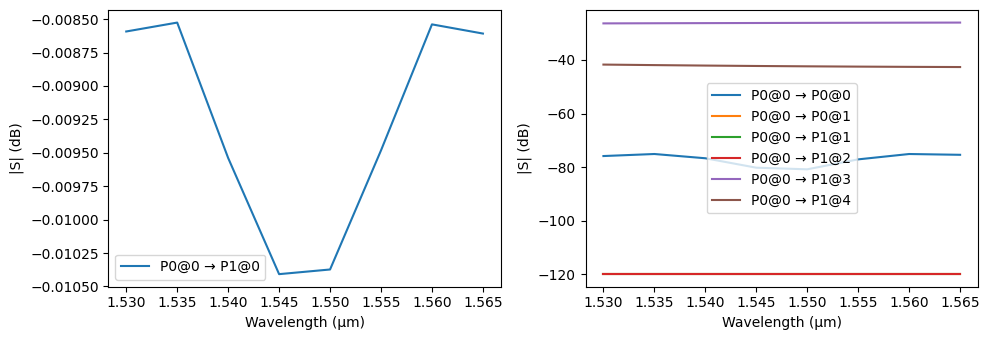

In [ ]:
_ = pf.plot_s_matrix(
    taper.s_matrix(frequencies=freqs, model_kwargs={"inputs": ["P0@0"]}), y="dB"
)

In [ ]:
#Y Splitter
@pf.parametric_component()
def y_splitter(*, s_offset, taper_length=25):
    c = pf.Component()

    core_width, _ = routing_spec.path_profile_for("LN_RIDGE")

    s_length = pf.s_bend_length(s_offset)

    for width, offset, layer in routing_spec.path_profiles:
        input_taper = pf.Path((0, 0), width, offset=offset)
        input_taper.segment((taper_length, 0), width + core_width)

        bottom_arm = pf.Path((taper_length, -0.5 * core_width), width, offset=offset)
        bottom_arm.s_bend((taper_length + s_length, -s_offset))

        top_arm = pf.Path((taper_length, 0.5 * core_width), width, offset=offset)
        top_arm.s_bend((taper_length + s_length, s_offset))

        # Heal the narrow regions for minimal feature size of approximately 100 nm
        path_list = pf.heal(
            [input_taper, bottom_arm, top_arm], 0.1 + pf.config.tolerance
        )

        c.add(layer, *path_list)

    # Add ports
    c.add_port(c.detect_ports([routing_spec]))

    # Add a model
    c.add_model(pf.Tidy3DModel(), model_name="Tidy3D")

    return c


s_offset = 0.5 * (arms.ports["P1"].center[1] - arms.ports["P0"].center[1])
splitter = y_splitter(s_offset=s_offset)
viewer(splitter)

In [ ]:
# create a monitor
field_xy = td.FieldMonitor(
    name="field_xy",
    center=(0, 0, 0.2),
    size=(td.inf, td.inf, 0),
    freqs=[freqs[len(freqs) // 2]],
)

# update the Tidy3DModel to add monitors
_ = splitter.models["Tidy3D"].update(monitors=[field_xy])

In [ ]:
s_matrix = splitter.s_matrix(frequencies=freqs, model_kwargs={"inputs": ["P0@0"]})

Uploading task 'P0@0'…
Starting task 'P0@0': https://tidy3d.simulation.cloud/workbench?taskId=fdve-4776c5d1-2b5e-463e-bd6b-e58667858600


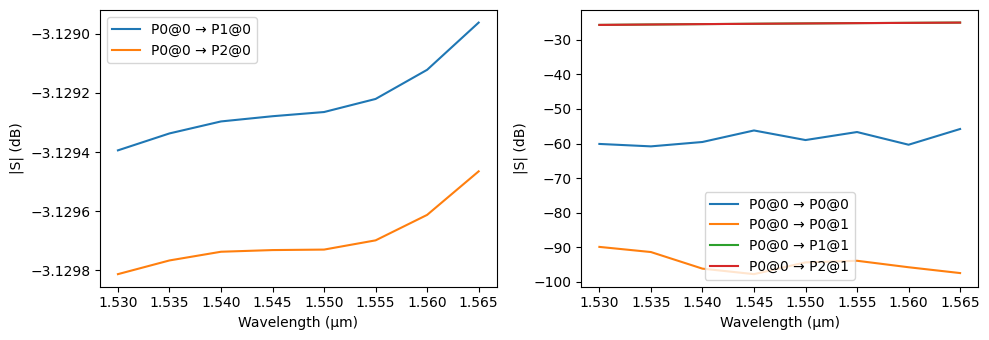

In [ ]:
_ = pf.plot_s_matrix(s_matrix, y="dB")

In [ ]:
sim_data = splitter.models["Tidy3D"].batch_data_for(splitter)
sim_data.task_ids

{'P0@0': 'fdve-4776c5d1-2b5e-463e-bd6b-e58667858600'}

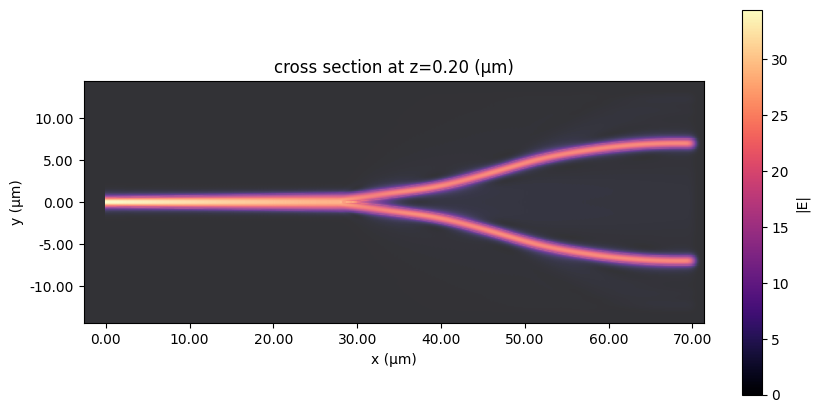

In [ ]:
# visualize the fields
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
_ = sim_data["P0@0"].plot_field("field_xy", "E", "abs", robust=False, ax=ax)

In [ ]:
#EO-MZM
@pf.parametric_component()
def eo_mzm():
    netlist = {
        "instances": {
            "y_in": splitter,
            "y_out": splitter,
            "arms": arms,
            "taper_in0": taper,
            "taper_in1": taper,
            "taper_out0": taper,
            "taper_out1": taper,
        },
        "connections": [
            (("taper_in0", "P0"), ("y_in", "P1")),
            (("taper_in1", "P0"), ("y_in", "P2")),
            (("arms", "P0"), ("taper_in0", "P1")),
            (("taper_out0", "P1"), ("arms", "P2")),
            (("taper_out1", "P1"), ("arms", "P3")),
            (("y_out", "P1"), ("taper_out1", "P0")),
        ],
        "ports": [
            ("y_in", "P0"),
            ("y_out", "P0"),
        ],
        "models": [(pf.CircuitModel(), "Circuit")],
    }

    return pf.component_from_netlist(netlist)


mzm = eo_mzm()
viewer(mzm)

In [ ]:
# Edge COupler
edge_coupler = lxt.component.double_linear_inverse_taper()
viewer(edge_coupler)

In [ ]:
#Full chip
@pf.parametric_component()
def coupled_device(*, full_length=4000, coupler_length=20, reference_link=False):
    c = pf.Component()

    in_coupler = pf.Reference(edge_coupler)
    out_coupler = pf.Reference(edge_coupler, origin=(full_length, 0), rotation=180)
    c.add(in_coupler, out_coupler)

    if reference_link:
        c.add(pf.parametric.route(port1=in_coupler["P1"], port2=out_coupler["P1"]))
    else:
        mzm_ref = c.add_reference(mzm)
        mzm_ref.x_mid = full_length / 2

        if mzm_ref["P0"].center[0] < in_coupler["P1"].center[0]:
            raise RuntimeError("Device not long enough for the desired MZM.")

        c.add(
            pf.parametric.route(port1=in_coupler["P1"], port2=mzm_ref["P0"]),
            pf.parametric.route(port1=out_coupler["P1"], port2=mzm_ref["P1"]),
        )

    c.add_port([in_coupler["P0"], out_coupler["P0"]])

    c.add_model(pf.CircuitModel(), "Circuit")

    return c


device = coupled_device()
viewer(device)

In [ ]:
coupled_device(reference_link=True)

In [ ]:
num_devices = 3
io_gap = 250

main = pf.Component("MAIN")
main.add(
    pf.Reference(
        coupled_device(reference_link=True),
        rows=num_devices,
        spacing=(0, 2 * io_gap),
    ),
    pf.Reference(
        coupled_device(),
        origin=(0, io_gap),
        rows=num_devices,
        spacing=(0, 2 * io_gap),
    ),
)

# Contour
contour = pf.envelope(
    main, offset=io_gap, use_box=True, trim_x_min=True, trim_x_max=True
)
main.add("CHIP_CONTOUR", contour)

# Labels
label_gap = 30
x_end = contour.x_max - label_gap
for i in range(num_devices):
    main.add(
        "LABELS",
        *pf.text(f"REF {i+1} A", 20, origin=(label_gap, label_gap + io_gap * 2 * i)),
        *pf.text(
            f"MZM {i+1} A", 20, origin=(label_gap, label_gap + io_gap * (1 + 2 * i))
        ),
        *pf.text(
            f"REF {i+1} B",
            20,
            origin=(x_end, -label_gap + io_gap * 2 * i),
            rotation=180,
        ),
        *pf.text(
            f"MZM {i+1} B",
            20,
            origin=(x_end, -label_gap + io_gap * (1 + 2 * i)),
            rotation=180,
        ),
    )

viewer(main)

In [ ]:
main.write_gds("EO-MZM.gds")
pf.write_phf("EO-MZM.phf")

In [ ]:
@pf.parametric_component()
def directional_coupler(*, length=6.0, gap=0.2):
    c = pf.Component()

    # Use existing waveguide spec from the technology
    routing_spec = pf.config.default_technology.ports["RWG1000"]
    wg_width, _ = routing_spec.path_profile_for("LN_RIDGE")

    for width, offset, layer in routing_spec.path_profiles:
        # Top waveguide
        top = pf.Path((0, gap / 2 + offset), width=width, offset=offset)
        top.segment((length, gap / 2 + offset))

        # Bottom waveguide
        bottom = pf.Path((0, -gap / 2 - offset), width=width, offset=offset)
        bottom.segment((length, -gap / 2 - offset))

        paths = pf.heal([top, bottom], 0.1 + pf.config.tolerance)
        c.add(layer, *paths)

    c.add_port(c.detect_ports([routing_spec]))
    c.add_model(pf.Tidy3DModel(), model_name="Tidy3D")
    return c

coupler = directional_coupler()
viewer(coupler)


<ipython-input-48-d046fe0905f3>:1: RuntimeWarning: Component function '__main__.directional_coupler' previously registered will be overwritten.
  @pf.parametric_component()


In [ ]:
print(tech.ports.keys())


dict_keys(['UniCPW', 'SWG250', 'RWG3000', 'UniCPW-EO', 'RWG1000'])


In [ ]:
# Final simulation summary and completion
print("🎉 Tidy3D MZM Simulation Complete!")
print("📊 Simulation Summary:")
print(f"   • Run ID: {client.run_id}")
print(f"   • Project: Tidy3D MZM Electro-Optic Modulator Analysis")
print(f"   • Technology: LNOI400 (Lithium Niobate on Insulator)")
print(f"   • Wavelength: {lda} μm")
print(f"   • RF Frequency Range: {rf_freqs[0]/1e9:.1f} - {rf_freqs[-1]/1e9:.1f} GHz")
print(f"   • Voltage Sweep: 0-{len(voltages)-1} V")
print(f"   • Effective Index Variation: {n_eff[-1] - n_eff[0]:.6f}")

# Log final simulation summary
client.log(16,
    simulation_phase="simulation_complete",
    total_simulation_time_seconds=time.time() - mode_start_time,
    final_effective_index_variation=float(n_eff[-1] - n_eff[0]),
    voltage_sweep_range_v=[0, len(voltages)-1],
    rf_frequency_range_ghz=[rf_freqs[0]/1e9, rf_freqs[-1]/1e9],
    wavelength_um=lda,
    technology="LNOI400",
    status="completed",
    summary="Tidy3D MZM Electro-Optic Modulator Analysis completed successfully"
)

print("✅ All simulation data logged to OptixLog!")
print("🔗 View your simulation results at: https://optixlog.com")
